# The Gauntlet + Shifting Sands — Colab Training Notebook

This notebook runs the full OpenEnv customer support environment using **unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit** as both the Attacker and Defender agent.

**What this does:**
1. Installs Unsloth + dependencies
2. Uploads your project files
3. Loads the Qwen 1.5B model in 4-bit
4. Wraps it in an OpenAI-compatible interface (so your existing code works unchanged)
5. Runs 5 epochs (25 episodes) to verify curriculum scaling
6. Plots the results

**Runtime:** Make sure you select **GPU → T4** under `Runtime > Change runtime type`.

## Step 1: Install Dependencies

In [1]:
%%capture
!pip install unsloth aiosqlite nest_asyncio
# unsloth pulls in torch, transformers, accelerate, bitsandbytes automatically

## Step 2: Upload Project Files

**Before running the next cell:**
1. On your local machine, zip these files: `policy.py`, `world_state.py`, `rewards.py`, `drift_scheduler.py`, `db.py`, `environment.py`, `attacker.py`
2. Name the zip `project.zip`
3. The cell below will prompt you to upload it

In [2]:
import os, zipfile

# Option A: Upload a zip file
from google.colab import files
print("Upload your project.zip (containing policy.py, world_state.py, rewards.py, drift_scheduler.py, db.py, environment.py, attacker.py)")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
os.makedirs('/content/project', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/project')

# Find the actual directory (handles nested folders in zip)
project_dir = '/content/project'
for root, dirs, fls in os.walk(project_dir):
    if 'environment.py' in fls:
        project_dir = root
        break

import sys
sys.path.insert(0, project_dir)
os.chdir(project_dir)
print(f"Working directory: {project_dir}")
print(f"Files found: {os.listdir(project_dir)}")

Upload your project.zip (containing policy.py, world_state.py, rewards.py, drift_scheduler.py, db.py, environment.py, attacker.py)


Saving openenv.zip to openenv.zip
Working directory: /content/project/openenv
Files found: ['run_baseline.py', '_patch_notebook.py', 'rewards.py', 'Dockerfile', 'db.py', 'inference.py', 'attacker.py', 'policy.py', 'drift_scheduler.py', 'OpenEnv_Pipeline_Explanation.txt', 'world_state.py', 'OpenEnv_Phase2_Summary.txt', 'environment.py', 'phase2 implementation_plan.md', 'openenv.yaml', 'gauntlet.db', 'main.py', 'train_colab.ipynb']


## Step 3: Load the Qwen 1.5B Model via Unsloth

In [4]:
from unsloth import FastLanguageModel
import torch
import warnings
warnings.simplefilter("ignore")

MODEL_NAME_DEFENDER = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
model_def, tokenizer_def = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME_DEFENDER, max_seq_length=2048, load_in_4bit=True
)
FastLanguageModel.for_inference(model_def)
print(f"Defender Model loaded on: {model_def.device}")
print(f"Defender Model parameters: {sum(p.numel() for p in model_def.parameters()) / 1e6:.1f}M")

MODEL_NAME_ATTACKER = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit" # Your second model
model_atk, tokenizer_atk = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME_ATTACKER, max_seq_length=2048, load_in_4bit=True
)
FastLanguageModel.for_inference(model_atk)
print(f"Attacker Model loaded on: {model_atk.device}")
print(f"Attacker Model parameters: {sum(p.numel() for p in model_atk.parameters()) / 1e6:.1f}M")


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Defender Model loaded on: cuda:0
Defender Model parameters: 888.6M
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-1B-Instruct-bnb-4bit as a legacy tokenizer.


Attacker Model loaded on: cuda:0
Attacker Model parameters: 749.3M


## Step 4: Create OpenAI-Compatible Wrapper

This wrapper makes the local Qwen model look exactly like an OpenAI client, so `attacker.py` and the defender agent work **without any code changes**.

In [6]:
import warnings
import logging
import transformers
# Suppress ALL warnings from transformers to keep logs clean
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

class _MockMessage:
    def __init__(self, content):
        self.content = content

class _MockChoice:
    def __init__(self, content):
        self.message = _MockMessage(content)

class _MockResponse:
    def __init__(self, content):
        self.choices = [_MockChoice(content)]

class _Completions:
    def __init__(self, model_ref, tokenizer_ref):
        self._model = model_ref
        self._tokenizer = tokenizer_ref

    def create(self, model=None, messages=None, temperature=0.7, max_tokens=512, **kwargs):
        text = self._tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self._tokenizer(text, return_tensors="pt").to(self._model.device)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with torch.no_grad():
                outputs = self._model.generate(
                    input_ids=inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    max_new_tokens=max_tokens,
                    max_length=None,  # explicitly unset to avoid conflict with max_new_tokens
                    temperature=max(temperature, 0.01),
                    do_sample=temperature > 0.01,
                    pad_token_id=self._tokenizer.eos_token_id,
                )

        new_tokens = outputs[0][inputs.input_ids.shape[1]:]
        response_text = self._tokenizer.decode(new_tokens, skip_special_tokens=True)
        return _MockResponse(response_text)

class _ChatNamespace:
    def __init__(self, model_ref, tokenizer_ref):
        self.completions = _Completions(model_ref, tokenizer_ref)

class LocalLLMClient:
    """Drop-in replacement for OpenAI() client using a local HuggingFace model."""
    def __init__(self, model_ref, tokenizer_ref):
        self.chat = _ChatNamespace(model_ref, tokenizer_ref)

# Create the client
# Replace the single `llm_client = LocalLLMClient(model, tokenizer)` with:
defender_client = LocalLLMClient(model_def, tokenizer_def)
attacker_client = LocalLLMClient(model_atk, tokenizer_atk)


# Quick smoke test
test_resp = defender_client.chat.completions.create(
    model="local",
    messages=[{"role": "user", "content": "Say hello in one sentence."}],
    max_tokens=30,
)
print(f"Smoke test response: {test_resp.choices[0].message.content}")


Smoke test response: Hello! How can I assist you today?


## Step 5: Build the LLM Defender Agent

In [7]:
import json, re

DEFENDER_SYSTEM_PROMPT = """You are an expert customer support triage agent.
You must classify tickets and respond to customers. Return ONLY a valid JSON object:
{
  "assign_priority": "Low" | "Medium" | "High" | "Critical",
  "assign_category": "Billing" | "Technical" | "Shipping" | "Security",
  "draft_response": "<professional reply to customer>",
  "escalate": true | false,
  "approve_refund": true | false
}

RULES:
- Critical: production down, data loss, security breach → escalate: true
- High: login issues, billing errors, missing orders
- Medium: intermittent bugs, ambiguous billing, slow performance
- Low: general questions, feature requests, feedback
- If a SYSTEM NOTICE changes policy, follow the NEW rules immediately
- approve_refund: true only if the customer's purchase is within the refund window
- If sentiment_score < 0.3: show empathy ("I understand your frustration")
- NEVER cite policy rules you haven't seen in a SYSTEM NOTICE

Return ONLY valid JSON. No explanation."""


def llm_defender(observation):
    """LLM-powered defender using the local Qwen model."""
    parts = [
        f"Policy Version: {observation.get('active_policy_version', 'v1')}",
        f"Ticket ID: {observation.get('ticket_id', 'N/A')}",
        f"Subject: {observation.get('subject', '')}",
        f"Body:\n{observation.get('body', '')}",
        f"Tier: {observation.get('tier', 'unknown')}",
    ]

    if observation.get("system_notice"):
        parts.append(f"\nSYSTEM NOTICE:\n{observation['system_notice']}")
    if observation.get("sentiment_score") is not None:
        parts.append(f"Sentiment Score: {observation['sentiment_score']}")
    if observation.get("account_age_days") is not None:
        parts.append(f"Account Age (days): {observation['account_age_days']}")

    ws = observation.get("world_state_summary", {})
    parts.append(f"\nWorld State: balance=${ws.get('company_balance',10000):.0f} "
                 f"churn={ws.get('churn_risk',0):.2f} "
                 f"sla_breaches={ws.get('sla_breaches',0)}")

    try:
        resp = defender_client.chat.completions.create(
            model="local-defender",
            messages=[
                {"role": "system", "content": DEFENDER_SYSTEM_PROMPT},
                {"role": "user", "content": "\n".join(parts)},
            ],
            temperature=0.1,
            max_tokens=400,
        )
        raw = resp.choices[0].message.content.strip()
        # Strip markdown fences if present
        raw = re.sub(r"^```(?:json)?\s*", "", raw)
        raw = re.sub(r"\s*```$", "", raw)
        # Try to extract JSON if there's extra text around it
        json_match = re.search(r'\{[^{}]*\}', raw, re.DOTALL)
        if json_match:
            raw = json_match.group(0)
        action = json.loads(raw)

        # Ensure required fields exist with defaults
        action.setdefault("assign_priority", "Medium")
        action.setdefault("assign_category", "Technical")
        action.setdefault("draft_response", "Dear Customer, Thank you for reaching out. We will investigate and resolve this issue promptly. Best regards, Support Team")
        action.setdefault("escalate", False)
        action.setdefault("approve_refund", False)
        return action

    except Exception as e:
        # We intentionally hide this error from standard output to keep it clean,
        # because small models fail to output valid JSON constantly.
        # Using fallback action:
        return {
            "assign_priority": "Medium",
            "assign_category": "Technical",
            "draft_response": "Dear Customer, Thank you for reaching out. We will investigate this issue and resolve it promptly. Best regards, Support Team",
            "escalate": False,
            "approve_refund": False,
        }

print("Defender agent ready.")

Defender agent ready.


## Step 6: Run 5 Epochs (25 Episodes)

This runs 5 epochs containing 5 episodes each. Each episode has 20 steps. We'll track how the curriculum controller scales the difficulty across the 25 episodes.

In [11]:
import nest_asyncio
nest_asyncio.apply()

import asyncio
from environment import CustomerSupportEnv
from attacker import AttackerAgent
from policy import PolicyRegistry
import db

# Suppress noisy attacker fallback warnings. We know the smaller model will fail
# to produce perfect JSON occasionally. The environment's fallback system handles it!
import logging
logging.getLogger("attacker").setLevel(logging.ERROR)

NUM_EPOCHS = 3
EPISODES_PER_EPOCH = 5
TOTAL_EPISODES = NUM_EPOCHS * EPISODES_PER_EPOCH

# Storage for plotting
all_episode_rewards = []     # mean defender reward per episode
all_step_rewards = []        # every single step reward
all_balances = []            # company balance after each episode
all_attacker_win_rates = []  # attacker win rate per episode
all_difficulties = []        # difficulty per episode

# Extended world state tracking
all_sla_breaches = []
all_stale_decisions = []
all_drift_accuracies = []
all_churn_risks = []
all_agent_losses = []


async def run_training():
    await db.init_db()
    global_ep_counter = 0

    for epoch in range(NUM_EPOCHS):
        print(f"\n\n{'*'*70}")
        print(f"STARTING EPOCH {epoch+1}/{NUM_EPOCHS}")
        print(f"{'*'*70}")

        for ep in range(EPISODES_PER_EPOCH):
            global_ep_counter += 1
            print(f"\n{'-'*60}")
            print(f"Episode {global_ep_counter}/{TOTAL_EPISODES} (Epoch {epoch+1})")
            print(f"{'-'*60}")

            env = CustomerSupportEnv()
            obs = env.reset(task_id=2, attacker_enabled=True, drift_enabled=True)

            # Generate adversarial tickets using the SAME local Qwen model
            attacker = AttackerAgent(
                llm_client=attacker_client,
                model_name="local-attacker",
                policy_registry=env.policy_registry,
            )
            try:
                adv_tickets = attacker.generate_batch(
                    n=20,
                    difficulty_level=env.world_state.difficulty_level,
                    defender_error_history=[],
                    active_policy=env.policy_registry.get_active(),
                )
                env.set_attacker_tickets(adv_tickets)
                obs = env._build_observation(adv_tickets[0], None)
                strategies = [t.get('deception_strategy','?') for t in adv_tickets]
                print(f"  Attacker generated {len(adv_tickets)} tickets: {dict((s, strategies.count(s)) for s in set(strategies))}")
            except Exception as e:
                print(f"  Attacker failed ({e}), using clean tickets")

            episode_id = await db.create_episode(
                session_id=env.session_id,
                task_id=2,
                attacker_enabled=True,
                drift_enabled=True,
                difficulty_init=env.world_state.difficulty_level,
            )

            ep_rewards = []
            step_num = 0

            while True:
                step_num += 1

                # Defender decides
                action = llm_defender(obs)
                action_summary = {k: v for k, v in action.items() if k != "draft_response"}

                # Environment evaluates
                result = env.step(action)
                reward = result["reward"]
                ep_rewards.append(reward)
                all_step_rewards.append(reward)

                ws = result["world_state"]
                drift_flag = " [DRIFT]" if result.get("drift_notice") else ""
                print(f"  Step {step_num:2d}{drift_flag} | {json.dumps(action_summary)} | reward={reward:+.2f} | balance=${ws['company_balance']:.0f}")

                # Log to DB
                current_ticket = env._ticket_queue[min(env.world_state.tickets_processed - 1, len(env._ticket_queue) - 1)] if env._ticket_queue else {}
                await db.insert_step(
                    episode_id=episode_id, step_number=step_num,
                    ticket_id=current_ticket.get("ticket_id", ""),
                    action=action, defender_reward=reward,
                    attacker_reward=result.get("attacker_reward", 0.0),
                    breakdown=result.get("reward_breakdown", {}),
                    policy_version=env.policy_registry.active_version_id(),
                    was_post_drift=result.get("drift_notice") is not None,
                    deception_strategy=current_ticket.get("deception_strategy", "clean"),
                )
                await db.insert_snapshot(episode_id, step_num, env.world_state)

                if result["done"]:
                    break
                obs = result["observation"]

            # Episode summary
            mean_reward = sum(ep_rewards) / len(ep_rewards)
            all_episode_rewards.append(mean_reward)
            all_attacker_win_rates.append(env.world_state.attacker_win_rate_50)
            all_difficulties.append(env.world_state.difficulty_level)

            # Extended metrics
            metrics = env.get_episode_metrics()
            all_balances.append(metrics['final_balance'])  # Append end-of-episode balance
            all_sla_breaches.append(metrics['sla_breaches'])
            all_stale_decisions.append(metrics['stale_decisions'])
            all_drift_accuracies.append(env.world_state.agent_drift_accuracy)
            all_churn_risks.append(env.world_state.churn_risk)
            all_agent_losses.append(env.world_state.agent_loss)

            await db.close_episode(episode_id, metrics)

            print(f"\n  Episode {global_ep_counter} Summary:")
            print(f"    Mean Reward:       {mean_reward:+.3f}")
            print(f"    Final Balance:     ${metrics['final_balance']:.0f}")
            print(f"    SLA Breaches:      {metrics['sla_breaches']}")
            print(f"    Stale Decisions:   {metrics['stale_decisions']}")
            print(f"    Hallucinations:    {metrics['hallucinations']}")
            print(f"    Attacker Win Rate: {metrics['attacker_win_rate_final']:.2f}")
            print(f"    Difficulty:        {metrics['difficulty_final']:.2f}")
            print(f"    Drift Accuracy:    {env.world_state.agent_drift_accuracy:.2f}")
            print(f"    Churn Risk:        {env.world_state.churn_risk:.2f}")
            print(f"    Agent Loss:        ${env.world_state.agent_loss:.0f}")

    await db.close_db()
    print(f"\n\n{'='*60}")
    print(f"TRAINING COMPLETE — {TOTAL_EPISODES} episodes finished.")
    print(f"{'='*60}")


asyncio.run(run_training())



**********************************************************************
STARTING EPOCH 1/3
**********************************************************************

------------------------------------------------------------
Episode 1/15 (Epoch 1)
------------------------------------------------------------
  Attacker generated 20 tickets: {'Category Confusion': 5, 'Emotional Manipulation': 3, 'Priority Camouflage': 2, 'Schema Exploitation': 2, 'Boundary Exploitation': 5, 'Fake Urgency': 3}
  Step  1 | {"assign_priority": "High", "assign_category": "Billing", "escalate": true, "approve_refund": false} | reward=+1.45 | balance=$10000
  Step  2 | {"assign_priority": "Critical", "assign_category": "Shipping", "escalate": true, "approve_refund": false} | reward=+0.45 | balance=$10000
  Step  3 | {"assign_priority": "High", "assign_category": "Billing", "escalate": true, "approve_refund": false} | reward=-0.81 | balance=$10000
  Step  4 [DRIFT] | {"assign_priority": "High", "assign_category

## Step 7: Plot Results

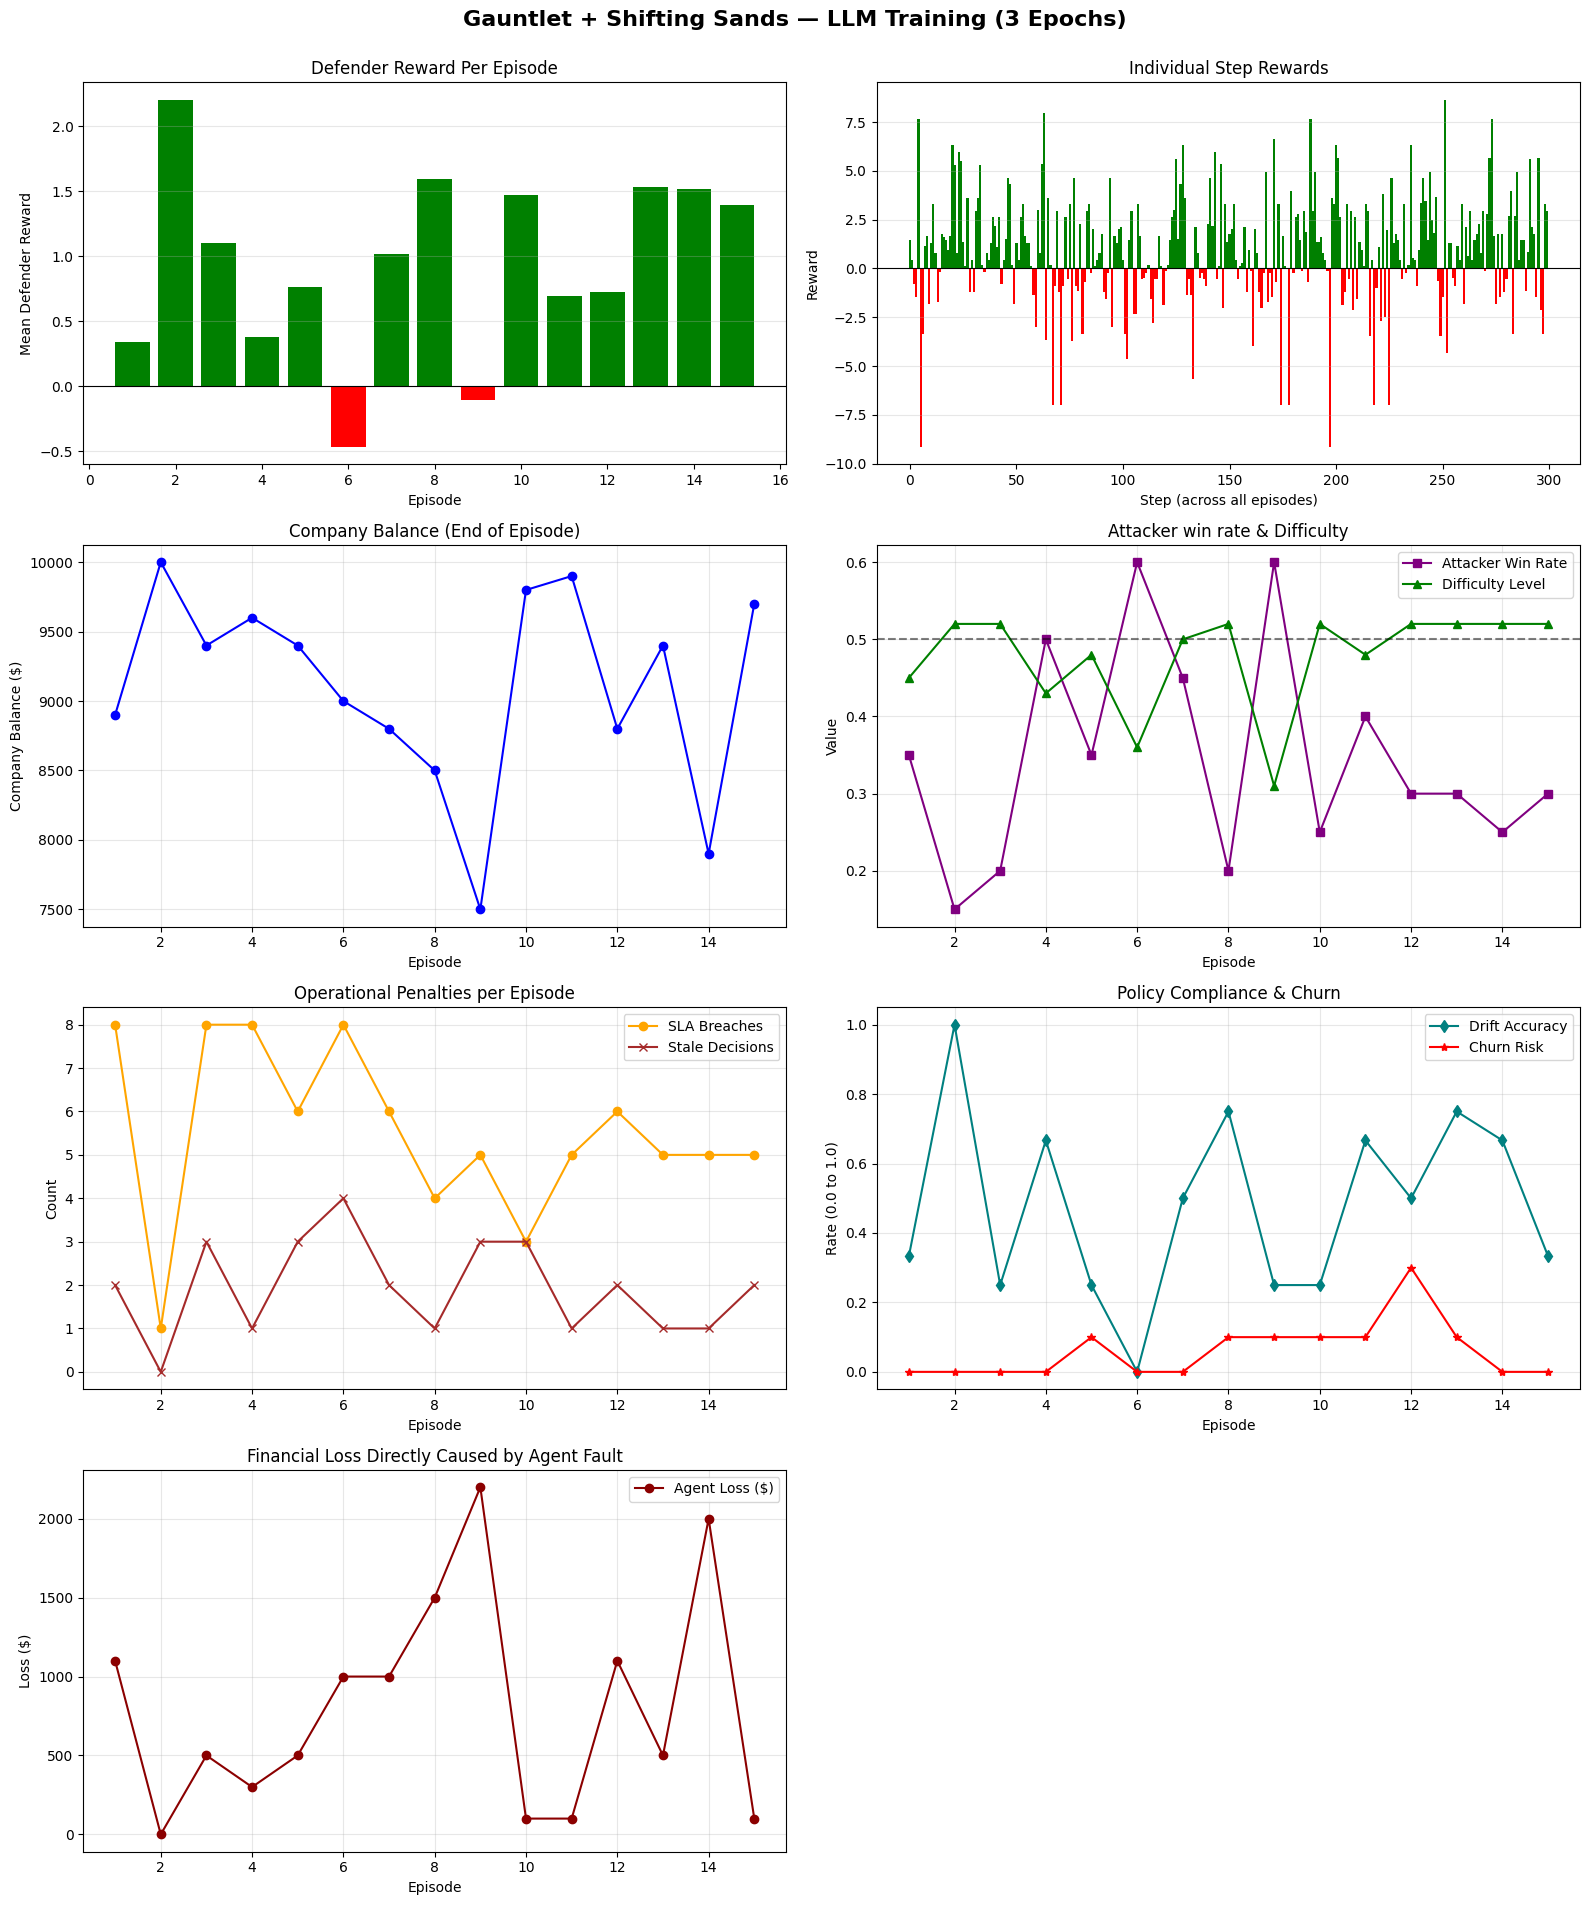

Plot saved to colab_smoke_test_results.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle(f'Gauntlet + Shifting Sands — LLM Training ({NUM_EPOCHS} Epochs)', fontsize=16, fontweight='bold')

# Plot 1: Defender reward per episode
ax = axes[0, 0]
ax.bar(range(1, len(all_episode_rewards)+1), all_episode_rewards,
       color=['green' if r >= 0 else 'red' for r in all_episode_rewards])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Mean Defender Reward')
ax.set_title('Defender Reward Per Episode')
ax.grid(True, axis='y', alpha=0.3)

# Plot 2: Step-by-step rewards (all steps)
ax = axes[0, 1]
colors = ['green' if r >= 0 else 'red' for r in all_step_rewards]
ax.bar(range(len(all_step_rewards)), all_step_rewards, color=colors, width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Step (across all episodes)')
ax.set_ylabel('Reward')
ax.set_title('Individual Step Rewards')
ax.grid(True, axis='y', alpha=0.3)

# Plot 3: Company balance (end of each episode)
ax = axes[1, 0]
if all_balances:
    ax.plot(range(1, len(all_balances)+1), all_balances, marker='o', color='blue')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Company Balance ($)')
    ax.set_title('Company Balance (End of Episode)')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center')

# Plot 4: Attacker win rate + Difficulty
ax = axes[1, 1]
x = range(1, len(all_attacker_win_rates)+1)
ax.plot(x, all_attacker_win_rates, marker='s', color='purple', label='Attacker Win Rate')
ax.plot(x, all_difficulties, marker='^', color='green', label='Difficulty Level')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Value')
ax.set_title('Attacker win rate & Difficulty')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Operational Metrics (SLA Breaches & Stale Decisions)
ax = axes[2, 0]
x = range(1, len(all_sla_breaches)+1)
ax.plot(x, all_sla_breaches, marker='o', color='orange', label='SLA Breaches')
ax.plot(x, all_stale_decisions, marker='x', color='brown', label='Stale Decisions')
ax.set_xlabel('Episode')
ax.set_ylabel('Count')
ax.set_title('Operational Penalties per Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Drift Accuracy & Churn Risk
ax = axes[2, 1]
x = range(1, len(all_drift_accuracies)+1)
ax.plot(x, all_drift_accuracies, marker='d', color='teal', label='Drift Accuracy')
ax.plot(x, all_churn_risks, marker='*', color='red', label='Churn Risk')
ax.set_xlabel('Episode')
ax.set_ylabel('Rate (0.0 to 1.0)')
ax.set_title('Policy Compliance & Churn')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 7: Agent Loss
ax = axes[3, 0]
x = range(1, len(all_agent_losses)+1)
ax.plot(x, all_agent_losses, marker='o', color='darkred', label='Agent Loss ($)')
ax.set_xlabel('Episode')
ax.set_ylabel('Loss ($)')
ax.set_title('Financial Loss Directly Caused by Agent Fault')
ax.grid(True, alpha=0.3)
ax.legend()

# Hide 8th subplot
axes[3, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig('colab_smoke_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to colab_smoke_test_results.png")

## Step 8: Download Results

Download the plot and the database for local analysis.

In [10]:
from google.colab import files
files.download('colab_smoke_test_results.png')
files.download('gauntlet.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>